# 구간화

구간화는 연속형 데이터를 특정 구간으로 나누어 범주형 또는 순위형으로 변환하는 방법

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'         # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 부호 깨짐 방지
plt.rcParams['figure.figsize'] = (10, 6)            # 기본 그래프 크기
plt.rcParams['figure.dpi'] = 100                    # 해상도

# Jupyter 노트북에서 그래프 인라인 표시
%matplotlib inline

print("라이브러리 로드 완료!")
print(f"matplotlib 버전: {plt.matplotlib.__version__}")
print(f"seaborn 버전: {sns.__version__}")

라이브러리 로드 완료!
matplotlib 버전: 3.8.3
seaborn 버전: 0.13.2


In [60]:
df = pd.read_csv(r'pandas/data/california_housing_test.csv')
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0


## 동일 길이로 구간화
pandas.cut()을 이용하여 특정 구간을 지정하여 범주형(순위형)데이터를 생성한다
1. 구간화하고자 하는 값과 함께 bins(범위), label(입력될 구간 데이터)
1. [10, 20, 30]으로 구간화하면 10 ~ 20, 20 ~ 30으로 두개로 구간화한다

In [61]:
# median_income 구간화하기
df_copy = df.copy()
print(df_copy['median_income'].describe())

df_copy['소득구간'] = pd.cut(df_copy['median_income'], bins=[0,2,3,5,8,df_copy['median_income'].max()], labels=['저소득', '서민층', '중산층', '고소득', '초고소득'])
df_copy.head()


count    3000.000000
mean        3.807272
std         1.854512
min         0.499900
25%         2.544000
50%         3.487150
75%         4.656475
max        15.000100
Name: median_income, dtype: float64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,소득구간
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,고소득
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,중산층
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,고소득
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,고소득
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,서민층


In [62]:
df_copy['소득구간'].value_counts()

소득구간
중산층     1298
서민층      733
고소득      524
저소득      360
초고소득      85
Name: count, dtype: int64

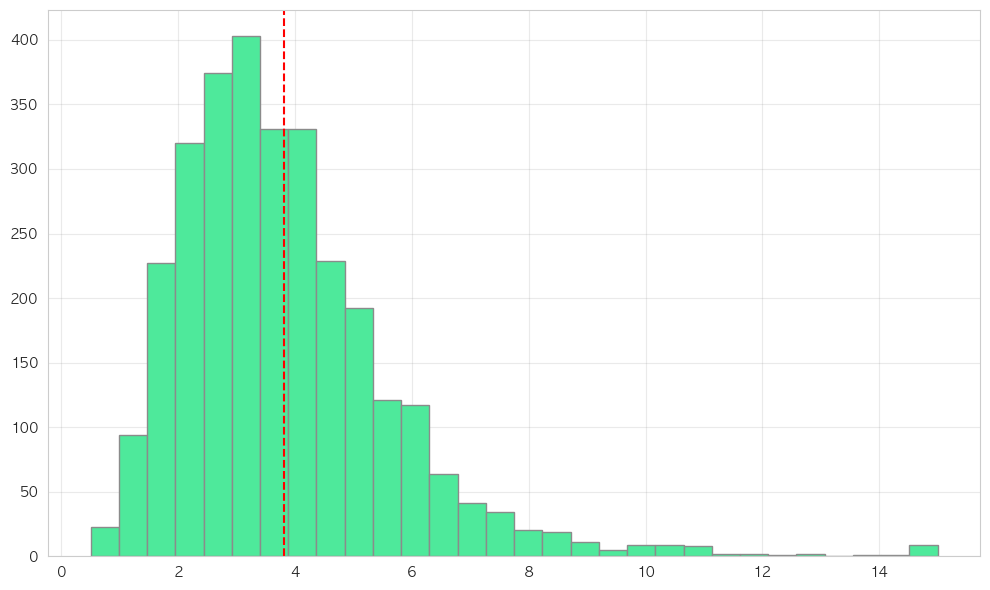

In [63]:
plt.hist(df_copy['median_income'], bins=30, color="#4ee99b", edgecolor="#8b8b8b" )
plt.axvline(df['median_income'].mean(), color='red', linestyle='--')
plt.grid(True, 'major', 'both', color="#989898", alpha=0.2)
plt.tight_layout()
plt.show()

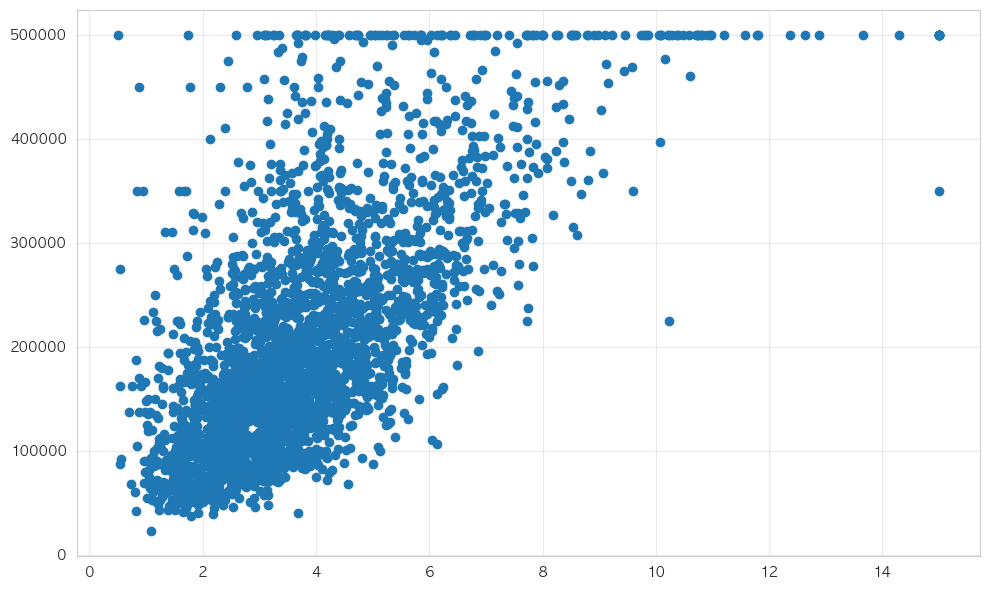

In [64]:
plt.scatter(x=df_copy['median_income'], y=df_copy['median_house_value'])
plt.grid(True, 'major', 'both', color="#989898", alpha=0.2)
plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

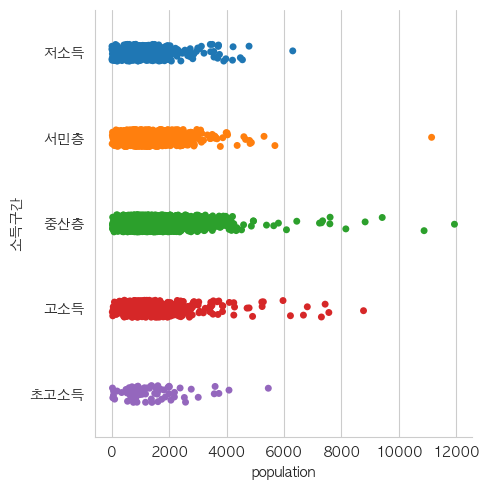

In [65]:
plt.figure(figsize=(12, 4))
sns.catplot(data=df_copy, x='population', y=df_copy['소득구간'], hue='소득구간')
plt.tight_layout()
plt.show()


<Axes: xlabel='소득구간', ylabel='count'>

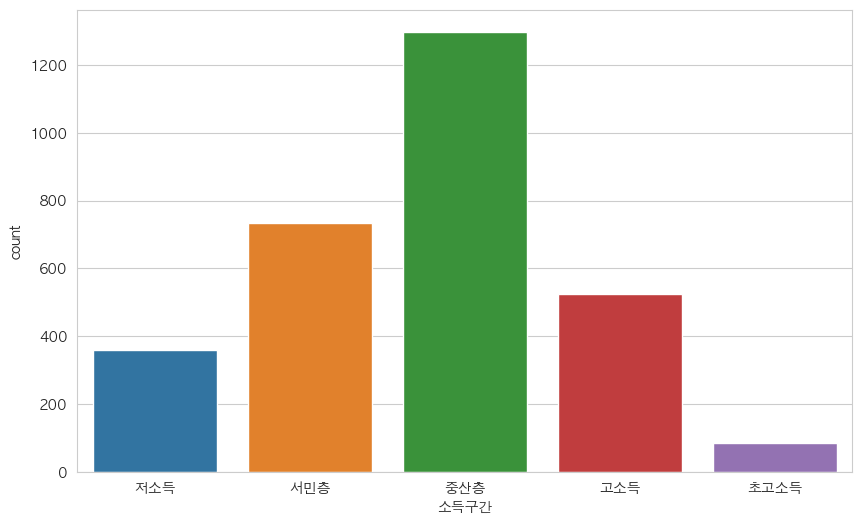

In [66]:
sns.countplot(data=df_copy, x='소득구간', hue='소득구간')

## 동일한 개수의 비율로 

pandas.qcut()을 이용하여 구간을 지정하여 범주형(순위형)데이터를 생성한다
1. 구간화할 개수를 지정하고 해당 구간에 동일한 데이터수가 들어가도록 지정
1. q에는 구간수(정수), label은 cut()과 동일한 방법

In [ ]:
# 동일한 비율로
df_copy['연령구간'] = pd.qcut(df_copy['housing_median_age'], q=5, labels=['Very New', 'New', 'Medium', 'Old', 'Very Old'])
df_copy.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,소득구간,연령구간
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,고소득,Medium
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,중산층,Very Old
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,고소득,Medium
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,고소득,Medium
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,서민층,New


<Axes: xlabel='연령구간', ylabel='count'>

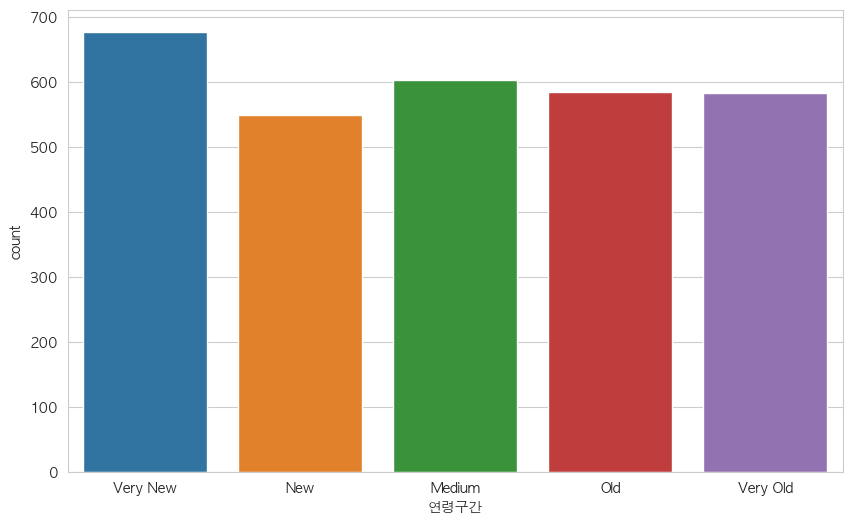

In [69]:
sns.countplot(data=df_copy, x='연령구간', hue='연령구간')

In [71]:
df_copy['연령구간'].value_counts()

연령구간
Very New    678
Medium      604
Old         585
Very Old    583
New         550
Name: count, dtype: int64